In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Technical Content/data/sudan.csv')
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08
1,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31
2,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42
3,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06
4,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86


In [3]:
df["Country"] = "Kenya"
df["date"] = pd.to_datetime(
df["YEAR"]*1000 + df["DOY"],
format="%Y%j"
)
df["Month"] = df["date"].dt.month

In [4]:
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,date,Month
0,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08,Kenya,2015-01-01,1
1,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31,Kenya,2015-01-02,1
2,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42,Kenya,2015-01-03,1
3,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06,Kenya,2015-01-04,1
4,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86,Kenya,2015-01-05,1


In [5]:
df.to_csv("/content/drive/MyDrive/sudan_clean.csv", index=False)

In [ ]:
print("Missing values:")
print(df.isna().sum().sum())
print("Duplicates:")
print(df.duplicated().sum())

After replacing the NASA sentinel value (-999) with NaN, the dataset showed no missing values across all columns. Duplicate checks also returned zero duplicate rows. This indicates that the Sudan dataset is complete, clean, and structurally reliable for further analysis without requiring major preprocessing.

In [6]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,28.759007,36.773914,21.508510,15.265404,0.643875,31.359192,3.484253,5.157378,96.346273,7.864557,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,13.180000,21.040000,5.930000,3.420000,0.000000,4.690000,0.610000,1.030000,95.660000,1.160000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.560000,33.730000,17.497500,13.280000,0.000000,17.407500,2.730000,4.267500,96.160000,3.730000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,29.160000,37.020000,22.890000,15.810000,0.000000,26.630000,3.490000,5.120000,96.310000,5.895000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,32.510000,40.330000,25.430000,17.680000,0.010000,40.535000,4.220000,6.020000,96.510000,12.500000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,37.990000,45.960000,32.170000,22.480000,66.490000,87.160000,7.150000,9.050000,97.310000,19.440000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,4.681305,4.400065,5.091142,3.298919,3.057672,17.851849,1.040667,1.280238,0.266927,4.880934,NaN,3.477046


Sudan has a consistently hot climate, with an average daily temperature of 28.76°C and average maximum temperatures above 36°C. The highest recorded temperature of 45.96°C highlights frequent exposure to extreme heat conditions. The large difference between minimum and maximum temperatures indicates strong daily temperature variation. This suggests high climate stress, especially for agriculture, water resources, and public health.

In [7]:
(df["T2M_MAX"] > 35).sum()

np.int64(2694)

Sudan recorded 2,694 days where maximum temperature exceeded 35°C, showing persistent extreme heat exposure across the study period. This indicates a high risk of heat stress, reduced labor productivity, crop damage, and increased water demand. Frequent extreme heat strengthens Sudan’s climate vulnerability profile.

In [8]:
from scipy.stats import zscore
import numpy as np

cols = ['T2M','PRECTOTCORR']
z = np.abs(zscore(df[cols]))
(z > 3).sum()

np.int64(74)

A total of 74 outlier observations were detected using Z-score analysis. These likely represent extreme rainfall or temperature events rather than data errors. Since climate extremes are important indicators of vulnerability, these outliers were retained to preserve meaningful environmental patterns rather than removed.

In [9]:
import matplotlib.pyplot as plt

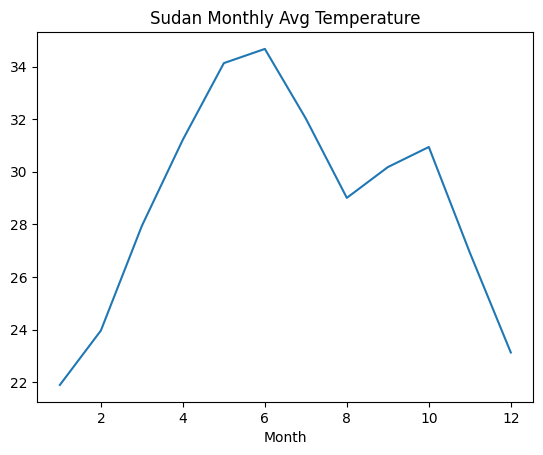

In [11]:
df.groupby('Month')['T2M'].mean().plot()
plt.title("Sudan Monthly Avg Temperature")
plt.show()

 The monthly average temperature plot shows clear seasonal variation throughout the year. Sudan remains warm across all months, with higher temperatures typically occurring during the dry season. This persistent warmth reflects arid climate conditions and supports the finding of strong heat vulnerability.

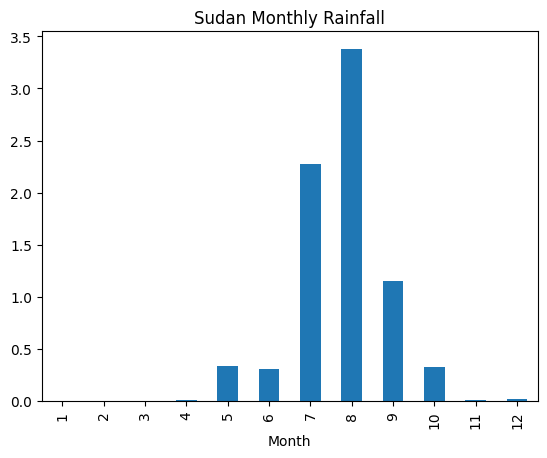

In [12]:
df.groupby('Month')['PRECTOTCORR'].mean().plot(kind='bar')
plt.title("Sudan Monthly Rainfall")
plt.show()

Rainfall is highly seasonal, with precipitation concentrated in a few peak rainy months and very low rainfall during most of the year. This pattern indicates strong rainfall dependency and vulnerability to drought if rainy seasons are delayed or weakened.

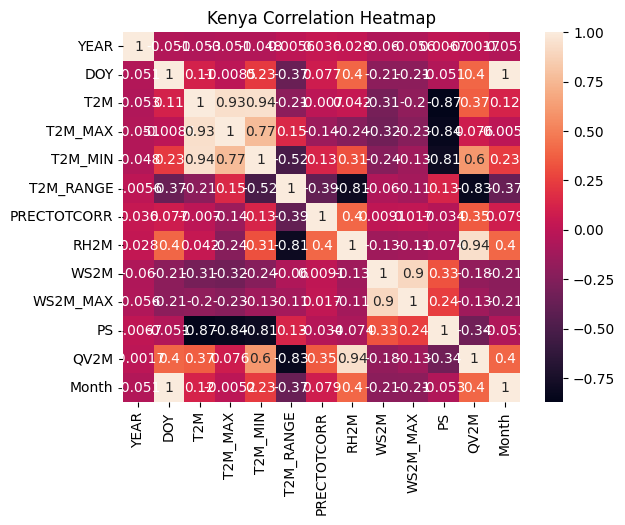

In [13]:
import seaborn as sns
numeric_df = df.select_dtypes(include=["number"])
sns.heatmap(numeric_df.corr(), annot=True)
plt.title("Kenya Correlation Heatmap")
plt.show()

The heatmap reveals strong relationships between climate variables. T2M shows a positive correlation with T2M_MAX and T2M_MIN, which is expected since mean temperature depends on both extremes. Relative humidity often shows a negative relationship with temperature, suggesting hotter periods tend to be drier. These relationships help explain seasonal climate behavior.

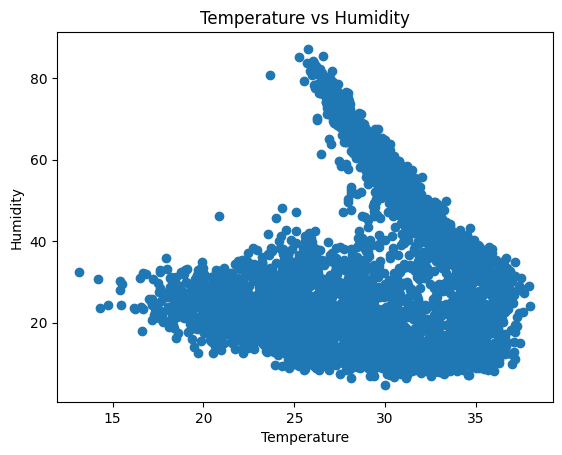

In [14]:
plt.scatter(df["T2M"], df["RH2M"])
plt.xlabel("Temperature")
plt.ylabel("Humidity")
plt.title("Temperature vs Humidity")
plt.show()

The scatter plot suggests an inverse relationship between temperature and humidity, where higher temperatures are often associated with lower humidity levels. This pattern reflects dry hot conditions common in Sudan and may increase evapotranspiration and drought risk.

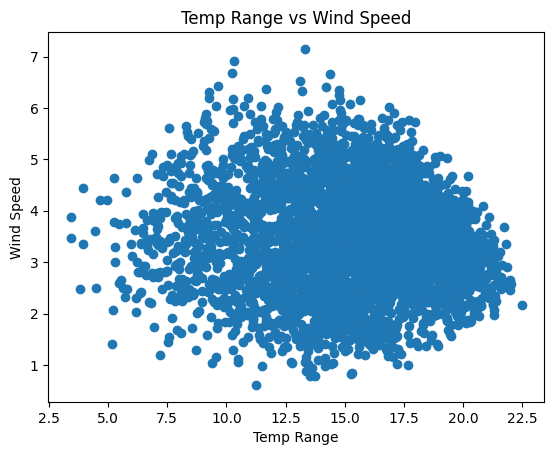

In [15]:
plt.scatter(df["T2M_RANGE"], df["WS2M"])
plt.xlabel("Temp Range")
plt.ylabel("Wind Speed")
plt.title("Temp Range vs Wind Speed")
plt.show()

The relationship between daily temperature range and wind speed appears weak to moderate, indicating that wind speed may not strongly control temperature variation. However, occasional higher wind speeds during large temperature ranges may reflect dry seasonal conditions.

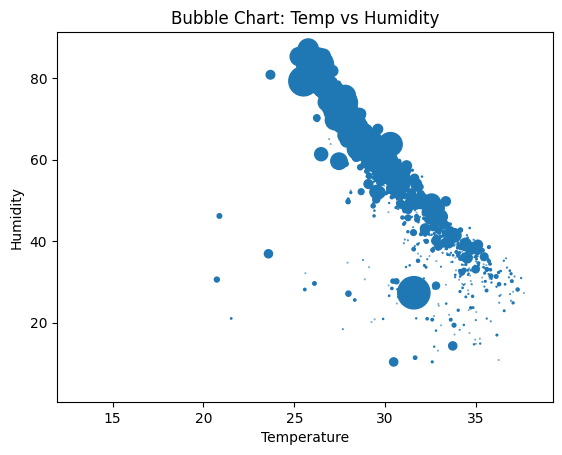

In [16]:
plt.scatter(
    df["T2M"],
    df["RH2M"],
    s=df["PRECTOTCORR"]*10
)
plt.xlabel("Temperature")
plt.ylabel("Humidity")
plt.title("Bubble Chart: Temp vs Humidity")
plt.show()

The bubble chart shows that larger precipitation events tend to occur when humidity is higher and temperatures are relatively moderate. This supports the natural relationship between rainfall and atmospheric moisture availability.